# Лабораторная работа №4: Линейные модели, SVM и деревья решений
Панасюк Ксения ИУ5-64Б

Цель лабораторной работы: изучение линейных моделей, SVM и деревьев решений.

Задание:

        Выберите набор данных (датасет) для решения задачи классификации или регрессии.
        В случае необходимости проведите удаление или заполнение пропусков и кодирование категориальных признаков.
        С использованием метода train_test_split разделите выборку на обучающую и тестовую.
        Обучите следующие модели:
            одну из линейных моделей (линейную или полиномиальную регрессию при решении задачи регрессии, логистическую регрессию при решении задачи классификации);
            SVM;
            дерево решений.
        Оцените качество моделей с помощью двух подходящих для задачи метрик. Сравните качество полученных моделей.
        Постройте график, показывающий важность признаков в дереве решений.
        Визуализируйте дерево решений или выведите правила дерева решений в текстовом виде.

# 1) Импорты и загрузка датасета

Был выбран датасет ирисы

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report

data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Первые 5 строк датасета:")
display(df.head())

Первые 5 строк датасета:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
# Разделение на признаки и целевую переменную
X = df.drop('target', axis=1)
y = df['target']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
# Обучение моделей

# Линейная модель (Логистическая регрессия)
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train_scaled, y_train)

# SVM
svm_model = SVC(kernel='linear')
svm_model.fit(X_train_scaled, y_train)

# Дерево решений
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [5]:
# оценка качества моделей
def evaluate_model(model, X_t, y_t, name):
    preds = model.predict(X_t)
    print(f"\n--- {name} ---")
    print(f"Accuracy: {accuracy_score(y_t, preds):.4f}")
    print("Classification Report:\n", classification_report(y_t, preds))

evaluate_model(log_reg, X_test_scaled, y_test, "Логистическая регрессия")
evaluate_model(svm_model, X_test_scaled, y_test, "SVM")
evaluate_model(tree_model, X_test, y_test, "Дерево решений")


--- Логистическая регрессия ---
Accuracy: 1.0000
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


--- SVM ---
Accuracy: 0.9778
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.92      0.96        13
           2       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45


--- Дерево решений ---
Accuracy: 1.0000
Classification Report:
               precision    recall  f1-score  

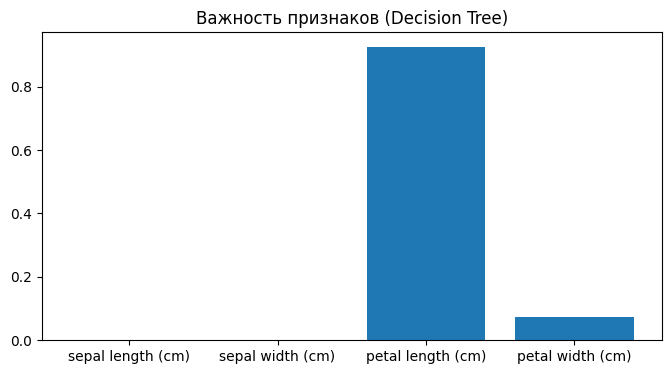


Правила дерева решений:
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.60
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.60
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- class: 2



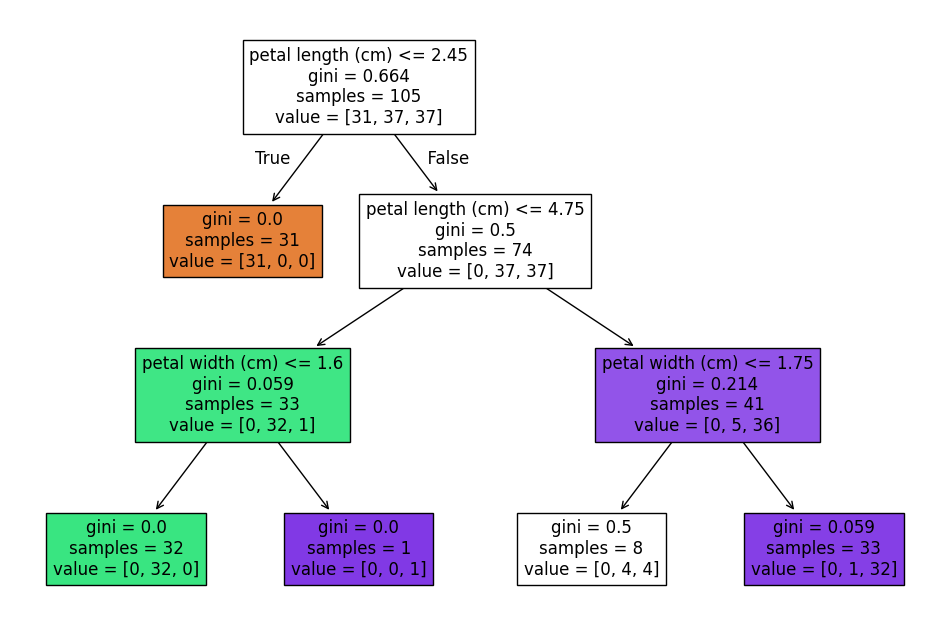

In [6]:
# Важность признаков
importances = tree_model.feature_importances_
plt.figure(figsize=(8, 4))
plt.bar(data.feature_names, importances)
plt.title("Важность признаков (Decision Tree)")
plt.show()

# Правила дерева
print("\nПравила дерева решений:")
print(export_text(tree_model, feature_names=list(data.feature_names)))

# Граф дерева
plt.figure(figsize=(12, 8))
plot_tree(tree_model, feature_names=data.feature_names, filled=True)
plt.show()